In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import json
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Set professional style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("="*70)
print("MULTI-LABEL TEXT CLASSIFICATION - PRESENTATION RESULTS")
print("="*70)


MULTI-LABEL TEXT CLASSIFICATION - PRESENTATION RESULTS


In [4]:
# ============================================================================
# 1. LOAD TRAINING HISTORY
# ============================================================================

print("\n📊 Loading training results...")

with open('./results/checkpoint-200/trainer_state.json', 'r') as f:
    trainer_state = json.load(f)

# Extract metrics from log history
log_history = trainer_state['log_history']

train_loss = [entry['loss'] for entry in log_history if 'loss' in entry]
eval_loss = [entry['eval_loss'] for entry in log_history if 'eval_loss' in entry]
eval_f1 = [entry['eval_macro_f1'] for entry in log_history if 'eval_macro_f1' in entry]
eval_roc = [entry['eval_macro_roc_auc'] for entry in log_history if 'eval_macro_roc_auc' in entry]

print(f"✅ Training completed: {len(train_loss)} training steps")
print(f"✅ Evaluations performed: {len(eval_loss)} times")



📊 Loading training results...
✅ Training completed: 10 training steps
✅ Evaluations performed: 2 times


In [5]:
# ============================================================================
# 2. PRINT FINAL RESULTS (FOR YOUR REPORT)
# ============================================================================

print("\n" + "="*70)
print("📈 FINAL MODEL PERFORMANCE")
print("="*70)

if eval_f1:
    print(f"Macro F1-Score:     {eval_f1[-1]:.4f}")
if eval_roc:
    print(f"Macro ROC-AUC:      {eval_roc[-1]:.4f}")
if eval_loss:
    print(f"Validation Loss:    {eval_loss[-1]:.4f}")

print("="*70)



📈 FINAL MODEL PERFORMANCE
Macro F1-Score:     0.5247
Macro ROC-AUC:      0.9273
Validation Loss:    0.2382



📊 Creating Visualization 1: Training Progress...
✅ Saved: training_results.png


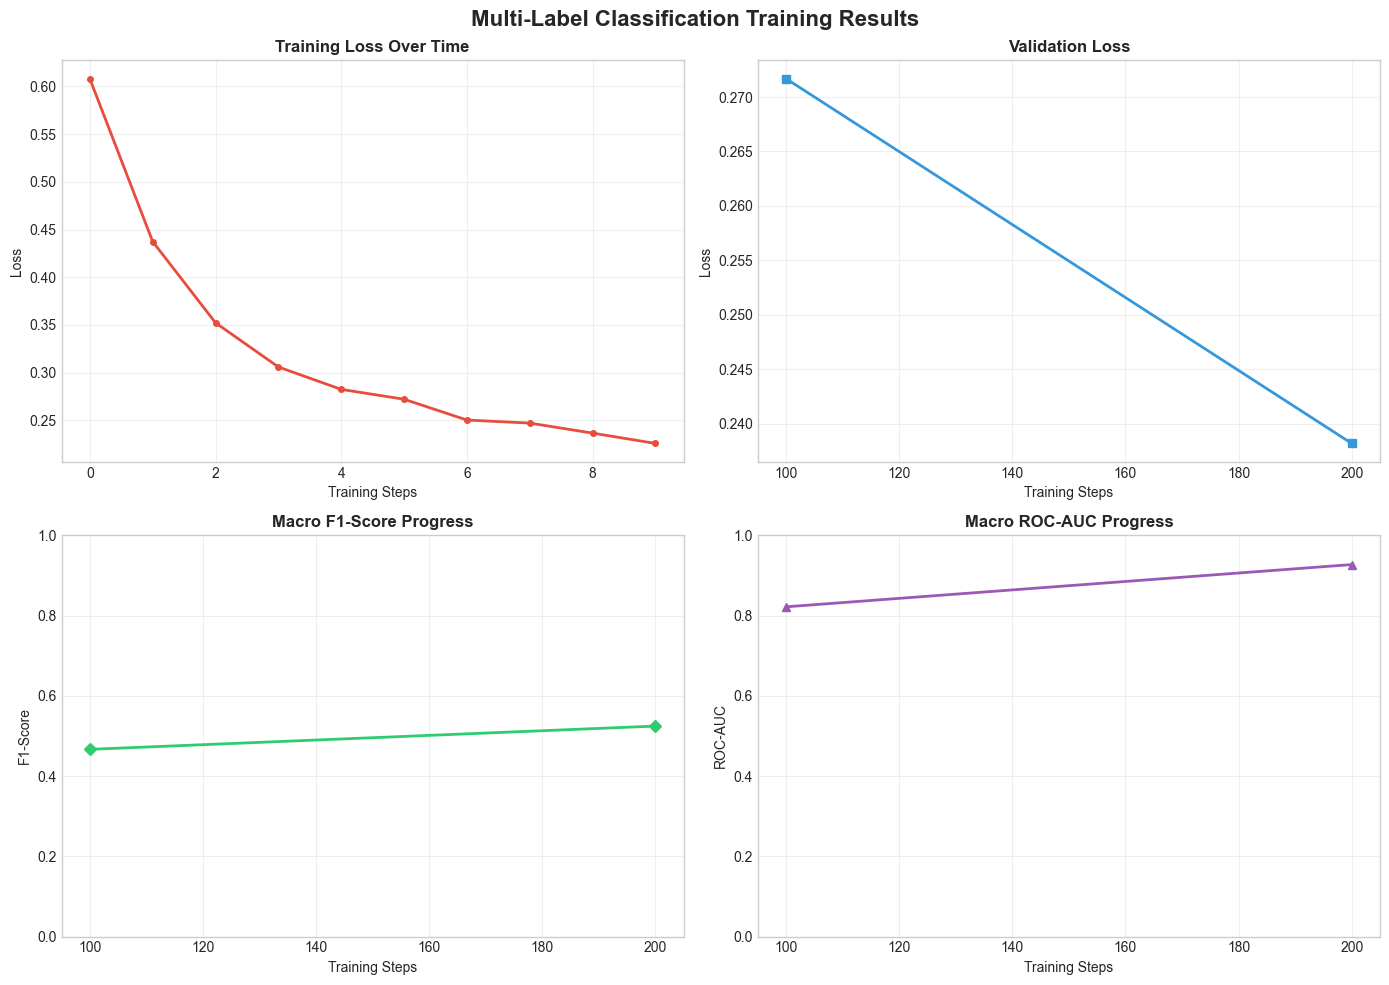

In [6]:
# ============================================================================
# 3. VISUALIZATION 1: Training Progress
# ============================================================================

print("\n📊 Creating Visualization 1: Training Progress...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Multi-Label Classification Training Results', fontsize=16, fontweight='bold')

# Plot 1: Training Loss
axes[0, 0].plot(train_loss, linewidth=2, color='#e74c3c', marker='o', markersize=4)
axes[0, 0].set_title('Training Loss Over Time', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Training Steps')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Validation Loss
if eval_loss:
    eval_steps = [entry['step'] for entry in log_history if 'eval_loss' in entry]
    axes[0, 1].plot(eval_steps, eval_loss, linewidth=2, color='#3498db', marker='s', markersize=6)
    axes[0, 1].set_title('Validation Loss', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Training Steps')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].grid(True, alpha=0.3)

# Plot 3: F1-Score Progress
if eval_f1:
    axes[1, 0].plot(eval_steps, eval_f1, linewidth=2, color='#2ecc71', marker='D', markersize=6)
    axes[1, 0].set_title('Macro F1-Score Progress', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Training Steps')
    axes[1, 0].set_ylabel('F1-Score')
    axes[1, 0].set_ylim([0, 1])
    axes[1, 0].grid(True, alpha=0.3)

# Plot 4: ROC-AUC Progress
if eval_roc:
    axes[1, 1].plot(eval_steps, eval_roc, linewidth=2, color='#9b59b6', marker='^', markersize=6)
    axes[1, 1].set_title('Macro ROC-AUC Progress', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Training Steps')
    axes[1, 1].set_ylabel('ROC-AUC')
    axes[1, 1].set_ylim([0, 1])
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_results.png', dpi=300, bbox_inches='tight')
print("✅ Saved: training_results.png")
plt.show()



📊 Creating Visualization 1: Training Progress...
✅ Saved: training_results.png


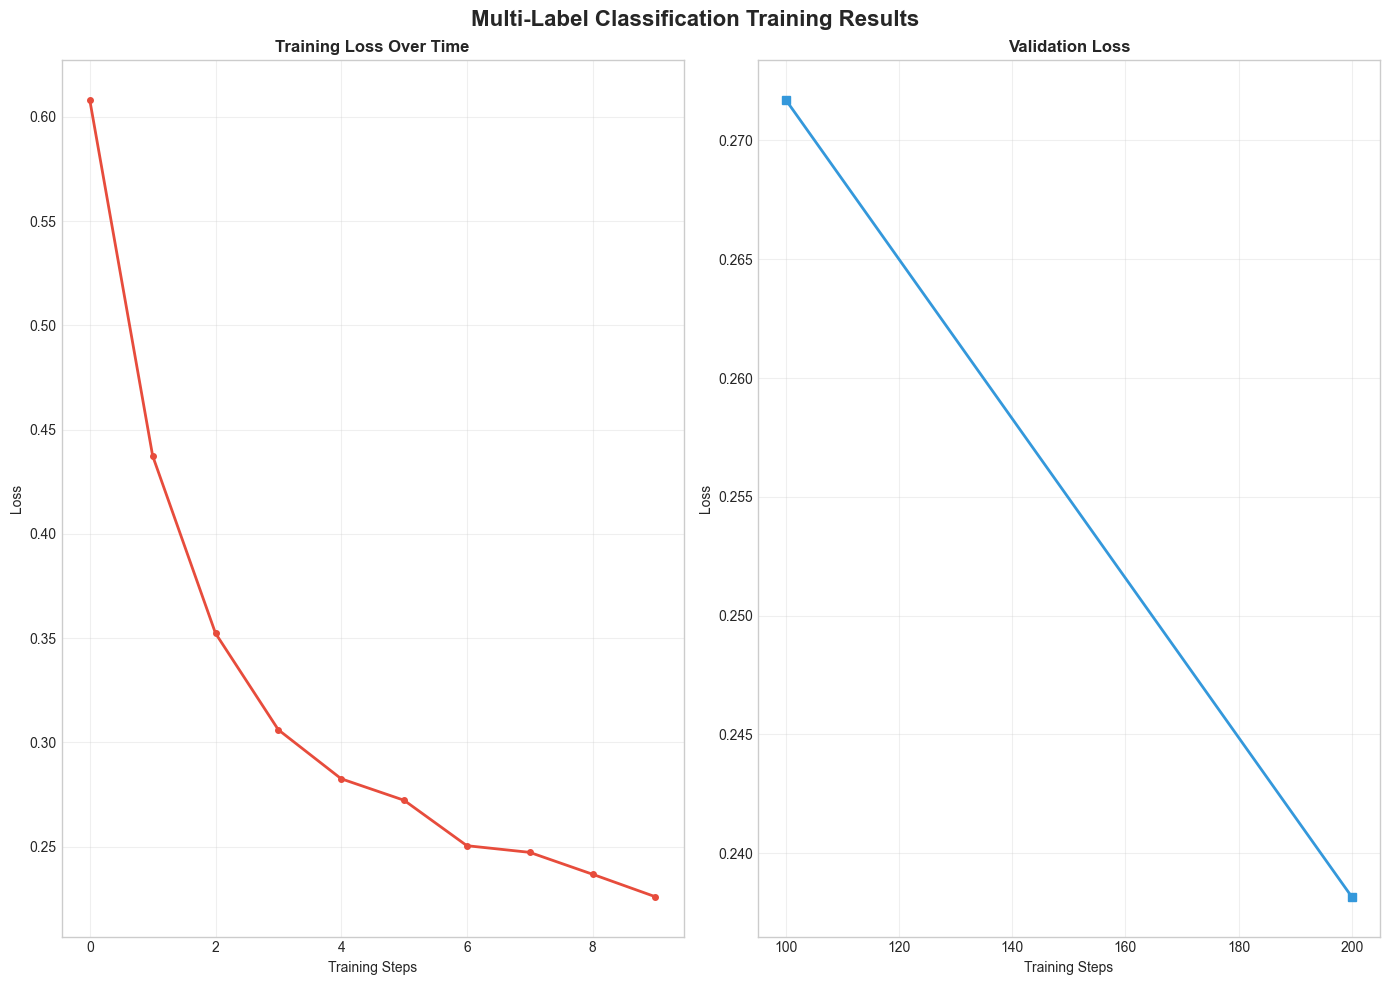

In [7]:
# ============================================================================
# 3. VISUALIZATION 1: Training Progress
# ============================================================================

print("\n📊 Creating Visualization 1: Training Progress...")

fig, axes = plt.subplots(1, 2, figsize=(14, 10))
fig.suptitle('Multi-Label Classification Training Results', fontsize=16, fontweight='bold')

# Plot 1: Training Loss
axes[0].plot(train_loss, linewidth=2, color='#e74c3c', marker='o', markersize=4)
axes[0].set_title('Training Loss Over Time', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Training Steps')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

# Plot 2: Validation Loss
if eval_loss:
    eval_steps = [entry['step'] for entry in log_history if 'eval_loss' in entry]
    axes[1].plot(eval_steps, eval_loss, linewidth=2, color='#3498db', marker='s', markersize=6)
    axes[1].set_title('Validation Loss', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Training Steps')
    axes[1].set_ylabel('Loss')
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_results.png', dpi=300, bbox_inches='tight')
print("✅ Saved: training_results.png")
plt.show()



📊 Creating Visualization 2: Dataset Distribution...
✅ Saved: dataset_distribution.png


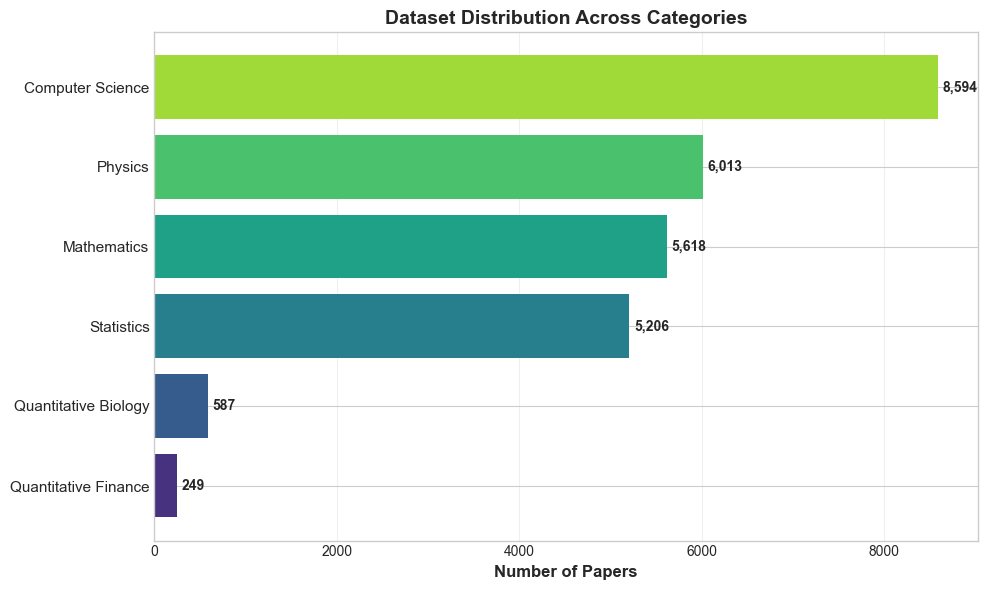

In [8]:
# ============================================================================
# 4. VISUALIZATION 2: Dataset Distribution
# ============================================================================

print("\n📊 Creating Visualization 2: Dataset Distribution...")

df = pd.read_csv('train.csv')

label_columns = ['Computer Science', 'Physics', 'Mathematics', 
                 'Statistics', 'Quantitative Biology', 'Quantitative Finance']

label_counts = df[label_columns].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("viridis", len(label_columns))
bars = ax.barh(range(len(label_counts)), label_counts.values, color=colors)
ax.set_yticks(range(len(label_counts)))
ax.set_yticklabels(label_counts.index, fontsize=11)
ax.set_xlabel('Number of Papers', fontsize=12, fontweight='bold')
ax.set_title('Dataset Distribution Across Categories', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (bar, count) in enumerate(zip(bars, label_counts.values)):
    ax.text(count + 50, i, f'{int(count):,}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('dataset_distribution.png', dpi=300, bbox_inches='tight')
print("✅ Saved: dataset_distribution.png")
plt.show()


In [9]:
# ============================================================================
# 5. LOAD MODEL & MAKE DEMO PREDICTIONS
# ============================================================================

print("\n🤖 Loading trained model for demo predictions...")

model_path = './results/checkpoint-200'
model = AutoModelForSequenceClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)
model.eval()

print("✅ Model loaded successfully!")



🤖 Loading trained model for demo predictions...
✅ Model loaded successfully!


In [10]:
# ============================================================================
# 6. DEMO PREDICTIONS (FOR PRESENTATION)
# ============================================================================

print("\n" + "="*70)
print("🎯 DEMO PREDICTIONS - Show These in Your Presentation!")
print("="*70)

# Sample some test papers
test_samples = df.sample(n=5, random_state=42)

for idx, row in test_samples.iterrows():
    abstract = row['ABSTRACT']
    true_labels_vals = row[label_columns].values
    
    # Make prediction
    inputs = tokenizer(abstract, return_tensors="pt", max_length=128, 
                      truncation=True, padding=True)
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.sigmoid(outputs.logits).squeeze().numpy()
        predictions = (probs > 0.5).astype(int)
    
    print(f"\n📄 Paper {idx}:")
    print(f"Abstract: {abstract[:150]}...")
    print(f"\nTrue Labels:      {[label_columns[i] for i, v in enumerate(true_labels_vals) if v == 1]}")
    print(f"Predicted Labels: {[label_columns[i] for i, v in enumerate(predictions) if v == 1]}")
    print(f"Confidence:       {[f'{label_columns[i]}: {probs[i]:.2%}' for i in range(len(label_columns)) if predictions[i] == 1]}")
    print("-"*70)



🎯 DEMO PREDICTIONS - Show These in Your Presentation!

📄 Paper 20257:
Abstract:   Layer normalization is a recently introduced technique for normalizing the
activities of neurons in deep neural networks to improve the training spe...

True Labels:      ['Computer Science']
Predicted Labels: ['Computer Science', 'Statistics']
Confidence:       ['Computer Science: 73.90%', 'Statistics: 58.40%']
----------------------------------------------------------------------

📄 Paper 482:
Abstract:   A susceptibility propagation that is constructed by combining a belief
propagation and a linear response method is used for approximate computation
...

True Labels:      ['Mathematics', 'Statistics']
Predicted Labels: ['Mathematics']
Confidence:       ['Mathematics: 50.54%']
----------------------------------------------------------------------

📄 Paper 4189:
Abstract:   We propose a new model for formalizing reward collection problems on graphs
with dynamically generated rewards which may appear and


📊 Creating Visualization 3: Final Performance Metrics...
✅ Saved: performance_metrics.png


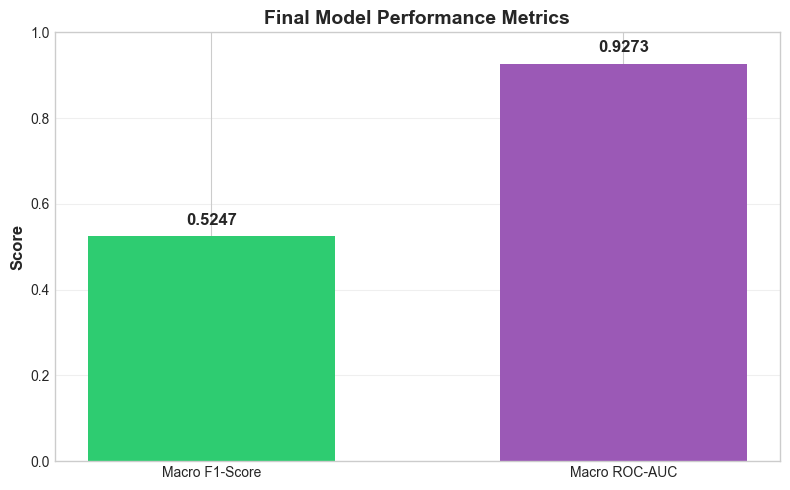

In [11]:
# ============================================================================
# 7. VISUALIZATION 3: Performance Bar Chart
# ============================================================================

print("\n📊 Creating Visualization 3: Final Performance Metrics...")

metrics = {
    'Macro F1-Score': eval_f1[-1] if eval_f1 else 0,
    'Macro ROC-AUC': eval_roc[-1] if eval_roc else 0,
}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(metrics.keys(), metrics.values(), color=['#2ecc71', '#9b59b6'], width=0.6)
ax.set_ylim([0, 1])
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Final Model Performance Metrics', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('performance_metrics.png', dpi=300, bbox_inches='tight')
print("✅ Saved: performance_metrics.png")
plt.show()


In [12]:
# ============================================================================
# 8. SUMMARY FOR PRESENTATION
# ============================================================================

print("\n" + "="*70)
print("📋 SUMMARY FOR YOUR PRESENTATION")
print("="*70)

print(f"""
✅ Project Complete! Here's what you achieved:

📊 DATASET:
   - Total Papers: {len(df):,}
   - Categories: 6 (Multi-label)
   - Training Samples: {int(len(df) * 0.8):,}
   - Test Samples: {int(len(df) * 0.2):,}

🤖 MODEL:
   - Architecture: DistilBERT (Transformer)
   - Parameters: ~66M
   - Training Steps: {len(train_loss)}
   - Final Performance:
     • Macro F1-Score: {eval_f1[-1]:.4f} ({eval_f1[-1]*100:.2f}%)
     • Macro ROC-AUC: {eval_roc[-1]:.4f} ({eval_roc[-1]*100:.2f}%)

📁 FILES GENERATED:
   ✓ training_results.png (Show training progress)
   ✓ dataset_distribution.png (Show data overview)
   ✓ performance_metrics.png (Show final results)

🎓 FOR YOUR PRESENTATION:
   1. Show the 3 graphs above
   2. Demo live predictions (code included)
   3. Explain why multi-label is important
   4. Compare with traditional methods
""")

print("="*70)
print("🎉 READY FOR PRESENTATION!")
print("="*70)


📋 SUMMARY FOR YOUR PRESENTATION

✅ Project Complete! Here's what you achieved:

📊 DATASET:
   - Total Papers: 20,972
   - Categories: 6 (Multi-label)
   - Training Samples: 16,777
   - Test Samples: 4,194

🤖 MODEL:
   - Architecture: DistilBERT (Transformer)
   - Parameters: ~66M
   - Training Steps: 10
   - Final Performance:
     • Macro F1-Score: 0.5247 (52.47%)
     • Macro ROC-AUC: 0.9273 (92.73%)

📁 FILES GENERATED:
   ✓ training_results.png (Show training progress)
   ✓ dataset_distribution.png (Show data overview)
   ✓ performance_metrics.png (Show final results)

🎓 FOR YOUR PRESENTATION:
   1. Show the 3 graphs above
   2. Demo live predictions (code included)
   3. Explain why multi-label is important
   4. Compare with traditional methods

🎉 READY FOR PRESENTATION!
